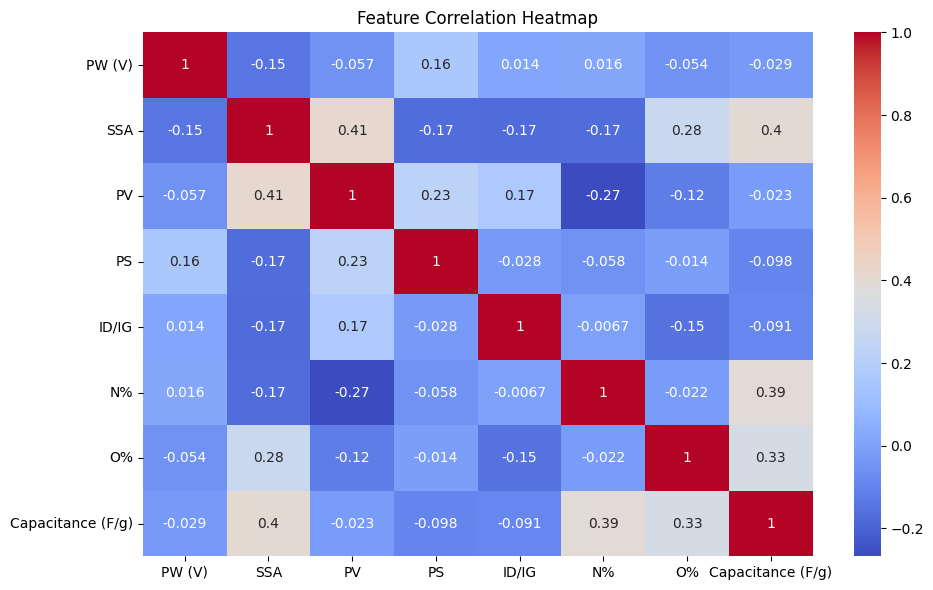

C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_m


Model Performance Comparison Table:

                   Model  RMSE   MAE  R² Score  Accuracy (%)
           Stacked Model 25.53 16.86      0.95         95.36
           Random Forest 26.96 17.35      0.95         94.82
                 XGBoost 29.58 17.98      0.94         93.77
           Decision Tree 53.68 39.18      0.79         79.47
Linear Regression (Poly) 67.81 51.32      0.67         67.25
             SVR (Tuned) 73.91 50.72      0.61         61.09
        Neural Net (MLP) 73.96 56.60      0.61         61.04


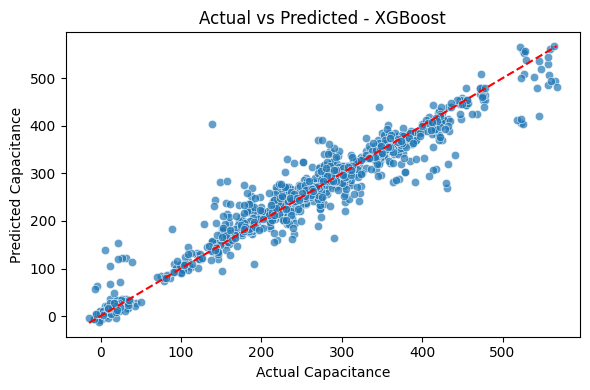

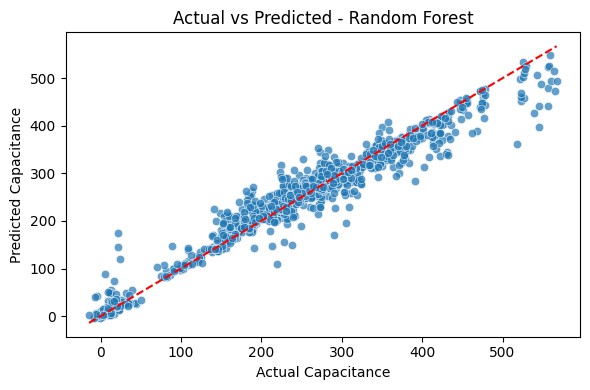

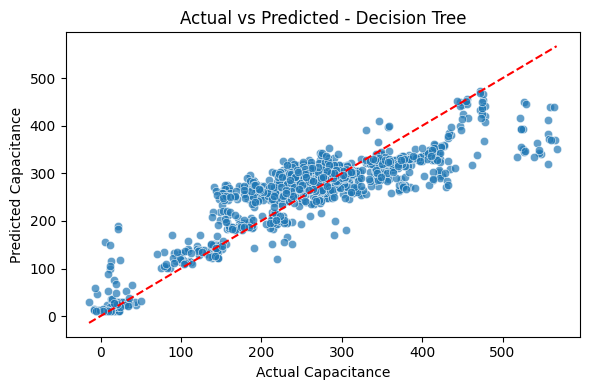

C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\singh\anaconda3\lib\site-packages\sklearn\neural_network\_m

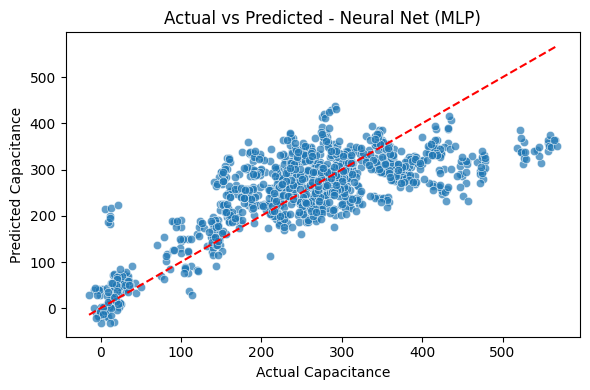

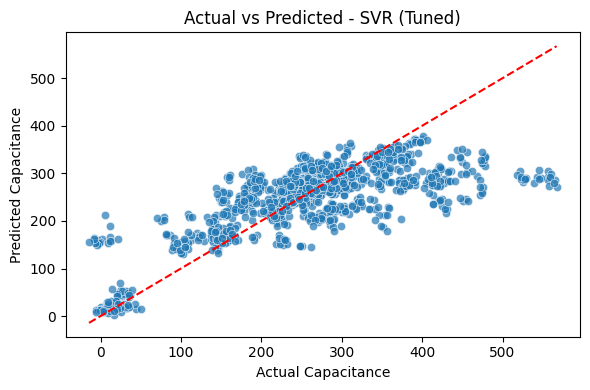

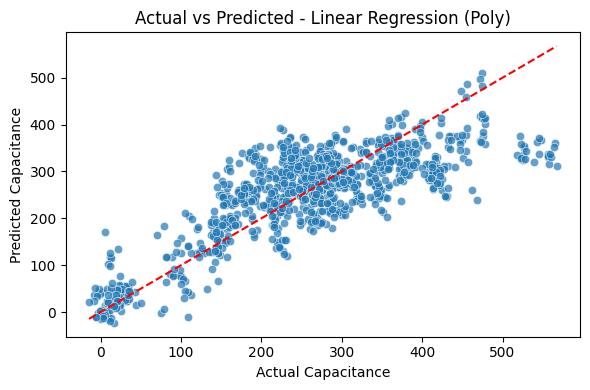

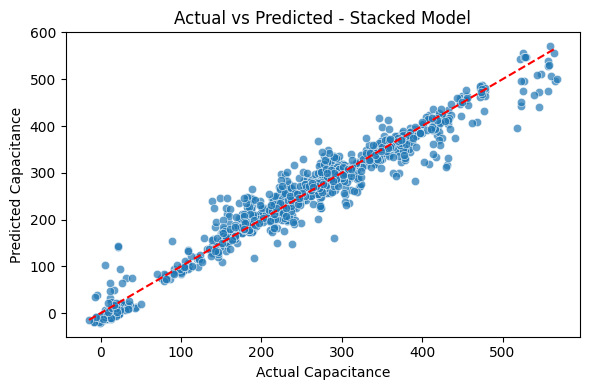

In [1]:
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load your final dataset (after cleaning/augmentation)
df = pd.read_csv("augmented_dataset_1200.csv")  # Replace with your file name

# Optional: Heatmap of Feature Correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Separate features and target
X = df.drop(columns=["Capacitance (F/g)"])
y = df["Capacitance (F/g)"]

# Define 10-Fold Cross-Validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Define models with custom pipelines for SVR and Linear Regression
models = {
    "XGBoost": XGBRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Decision Tree": RandomForestRegressor(max_depth=5, random_state=42),
    "Neural Net (MLP)": MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    "SVR (Tuned)": make_pipeline(StandardScaler(), SVR(C=10, epsilon=0.1, kernel='rbf')),
    "Linear Regression (Poly)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
}

# Define the Stacking Regressor
estimators = [
    ("rf", RandomForestRegressor(random_state=42)),
    ("xgb", XGBRegressor(random_state=42))
]
stacked_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression(),
    cv=5
)
models["Stacked Model"] = stacked_model

# Metrics Storage
results = []

for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    acc = r2 * 100
    results.append({
        "Model": name,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "R² Score": round(r2, 2),
        "Accuracy (%)": round(acc, 2)
    })

# Create and display performance comparison table
results_df = pd.DataFrame(results).sort_values(by="Accuracy (%)", ascending=False)
print("\nModel Performance Comparison Table:\n")
print(results_df.to_string(index=False))

# Plot Actual vs Predicted
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv)
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y, y=y_pred, alpha=0.7)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Actual Capacitance")
    plt.ylabel("Predicted Capacitance")
    plt.title(f"Actual vs Predicted - {name}")
    plt.tight_layout()
    plt.show()

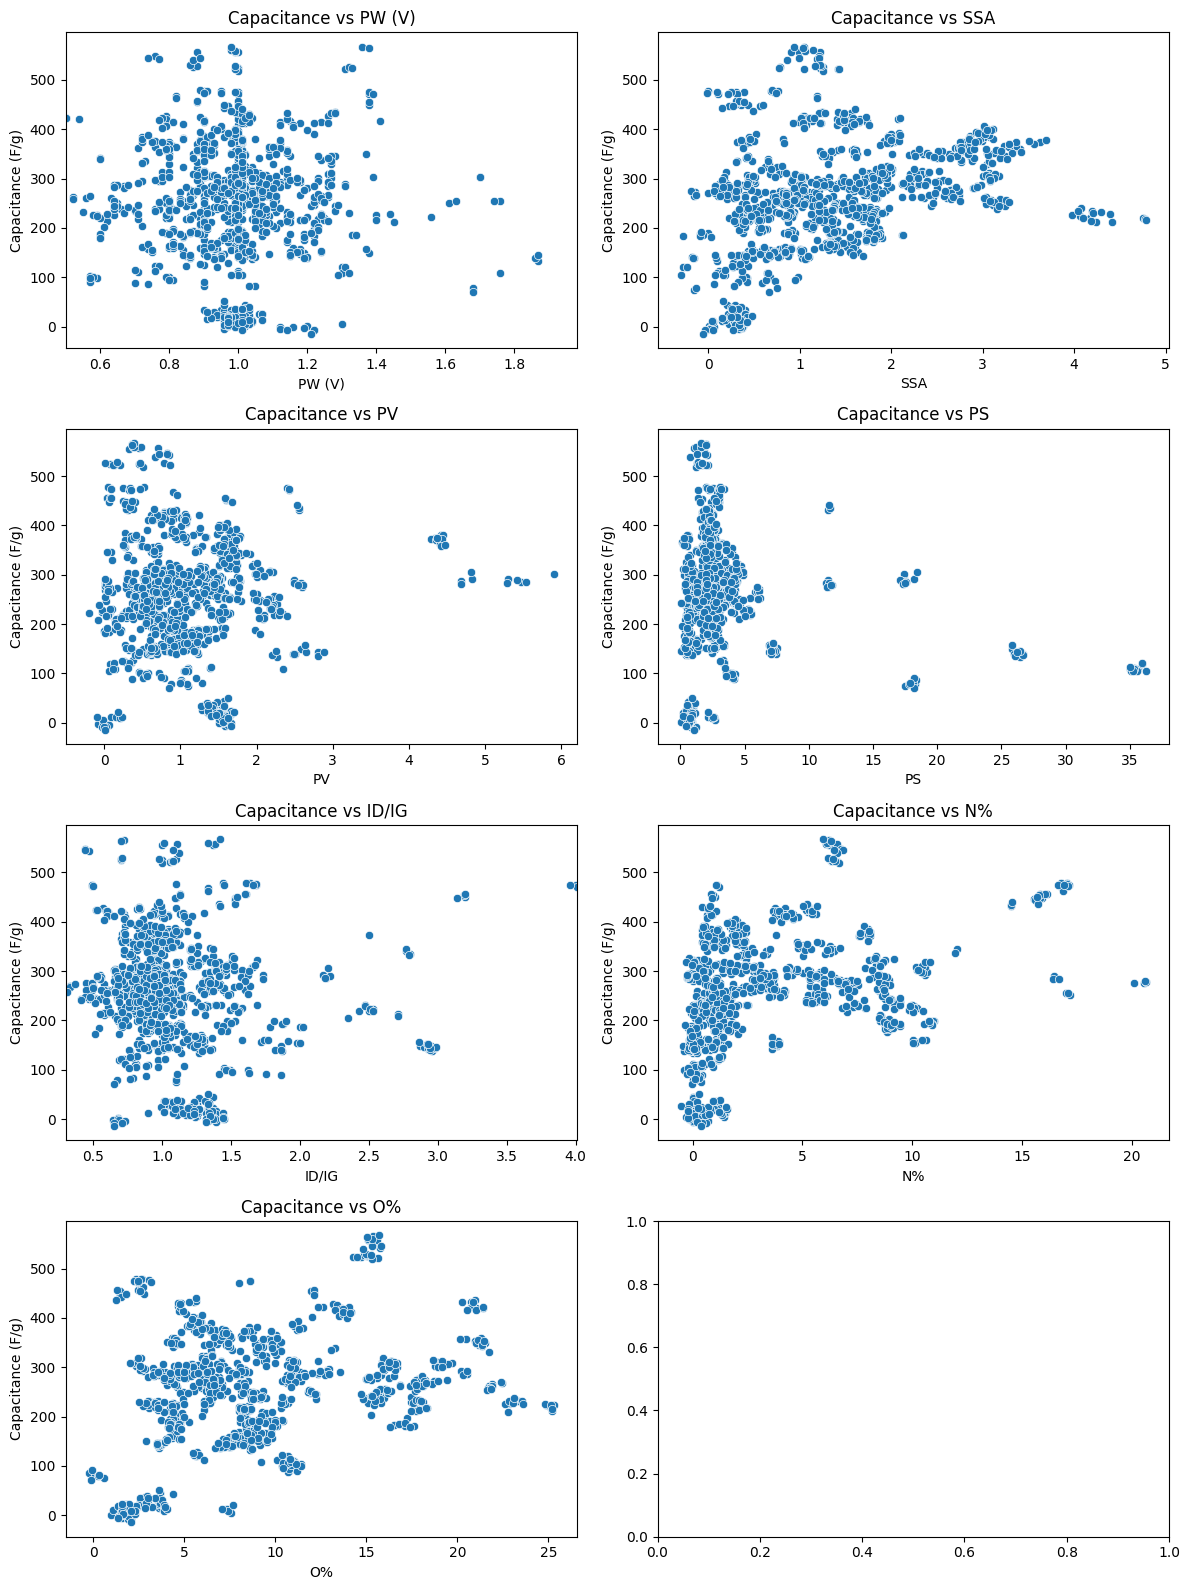

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset (after cleaning/augmentation)
df = pd.read_csv("augmented_dataset_1200.csv")  # Replace with your file name

# Separate features and target
X = df.drop(columns=["Capacitance (F/g)"])
y = df["Capacitance (F/g)"]

# Create a figure with multiple subplots (2 graphs per row)
fig, axes = plt.subplots(4, 2, figsize=(12, 16))  # 4 rows, 2 columns
axes = axes.flatten()

# List of features to plot
features = X.columns

# Plot each feature vs capacitance
for i, feature in enumerate(features):
    sns.scatterplot(x=X[feature], y=y, ax=axes[i])
    axes[i].set_title(f"Capacitance vs {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Capacitance (F/g)")

    # Adjust x and y limits based on conditions
    if feature == "ID/IG":  # Adjust ID/IG feature
        axes[i].set_xlim(0.3, X[feature].max())  # Start at 0.5 for x-axis

    # Explicitly set x-limit for "PW (V)" (Potential Window)
    if feature == "PW (V)":  # Corrected column name
        axes[i].set_xlim(left=0.5)  # Start the x-axis at 0.8

# Adjust layout for better presentation
plt.tight_layout()
plt.show()


C:\Users\singh\AppData\Local\Temp\ipykernel_25480\3022557257.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summary_table.rename(columns={'mean': 'Feature Mean', 'std': 'Std Dev', 'min': 'Min',


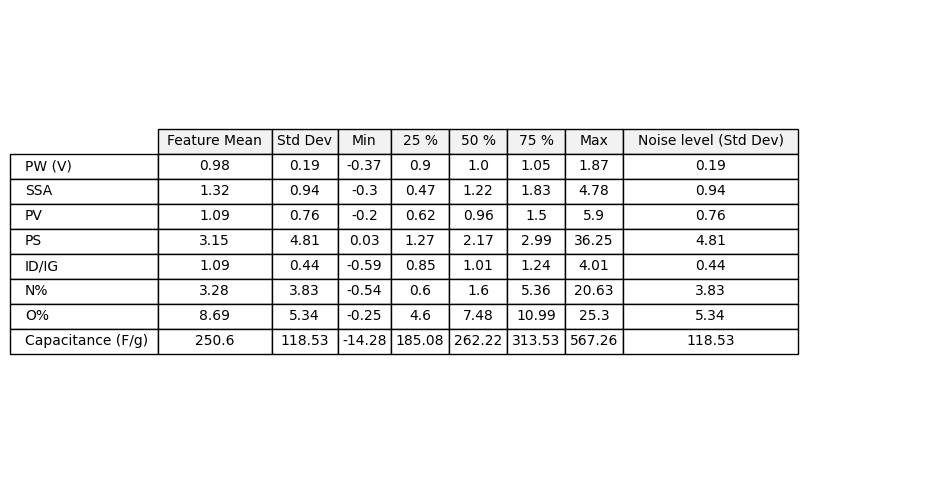

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Your dataset (after cleaning/augmentation)
df = pd.read_csv("augmented_dataset_1200.csv")  # Replace with your file name

# Calculate summary statistics
summary_stats = df.describe().transpose()

# Add noise level (std dev)
summary_stats['Noise level (Std Dev)'] = summary_stats['std']

# Create a summary table in the format you want
summary_table = summary_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'Noise level (Std Dev)']]
summary_table.rename(columns={'mean': 'Feature Mean', 'std': 'Std Dev', 'min': 'Min', 
                              '25%': '25 %', '50%': '50 %', '75%': '75 %', 'max': 'Max'}, inplace=True)

# Round the values to 2 decimal places
summary_table = summary_table.round(2)

# Plot the table
fig, ax = plt.subplots(figsize=(12, 6))  # Adjusted the size for better fit
ax.axis('off')  # Turn off axis

# Use Matplotlib's table feature to plot the DataFrame
table = ax.table(cellText=summary_table.values,
                colLabels=summary_table.columns,
                rowLabels=summary_table.index,
                loc='center',
                cellLoc='center',
                colColours=['#f2f2f2']*summary_table.shape[1])  # Optional: Add color to columns

# Adjust table appearance for better formatting
table.auto_set_font_size(False)
table.set_fontsize(10)  # Font size adjustment
table.scale(1.5, 1.5)  # Adjust table scaling (increase if table is still too compressed)

# Adjust column width dynamically by estimating the max length of the content
for i in range(len(summary_table.columns)):
    max_len = max(summary_table[summary_table.columns[i]].apply(lambda x: len(str(x))))  # Get max length for each column
    table.auto_set_column_width([i])  # Set column width based on max length

plt.show()
